# Vector Stores Comparison : FAISS vs Qdrant vs Pgvector

This notebook visualizes the benchmark results comparing the three vector stores used in the CloudMind RAG pipeline across indexing speed, search speed, and similarity scores.

## Load Results

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# Load benchmark results
results_path = Path("../results/benchmarks/benchmark_results.json")
with open(results_path, "r") as f:
    results = json.load(f)

df = pd.DataFrame(results)
print("Results loaded")
print(f"Stores benchmarked: {df['store'].tolist()}")

Results loaded
Stores benchmarked: ['faiss', 'qdrant', 'pgvector']


In [2]:
display_df = df[["store", "n_documents", "indexing_time_s", "avg_search_time_s", "p95_latency_s", "throughput_qps", "avg_similarity_score"]].copy()
display_df.columns = ["Store", "Documents", "Indexing (s)", "Search (s)", "P95 (s)", "QPS", "Similarity"]
display_df = display_df.set_index("Store")
display_df.head()

,Documents,Indexing (s),Search (s),P95 (s),QPS,Similarity
Store,,,,,,
faiss,10438,0.2284,0.0028,0.0003,3603.53,0.7551
qdrant,10438,11.1793,0.1821,0.0330,54.90,0.7551
pgvector,10438,24.2170,0.5141,0.0595,19.45,0.7551


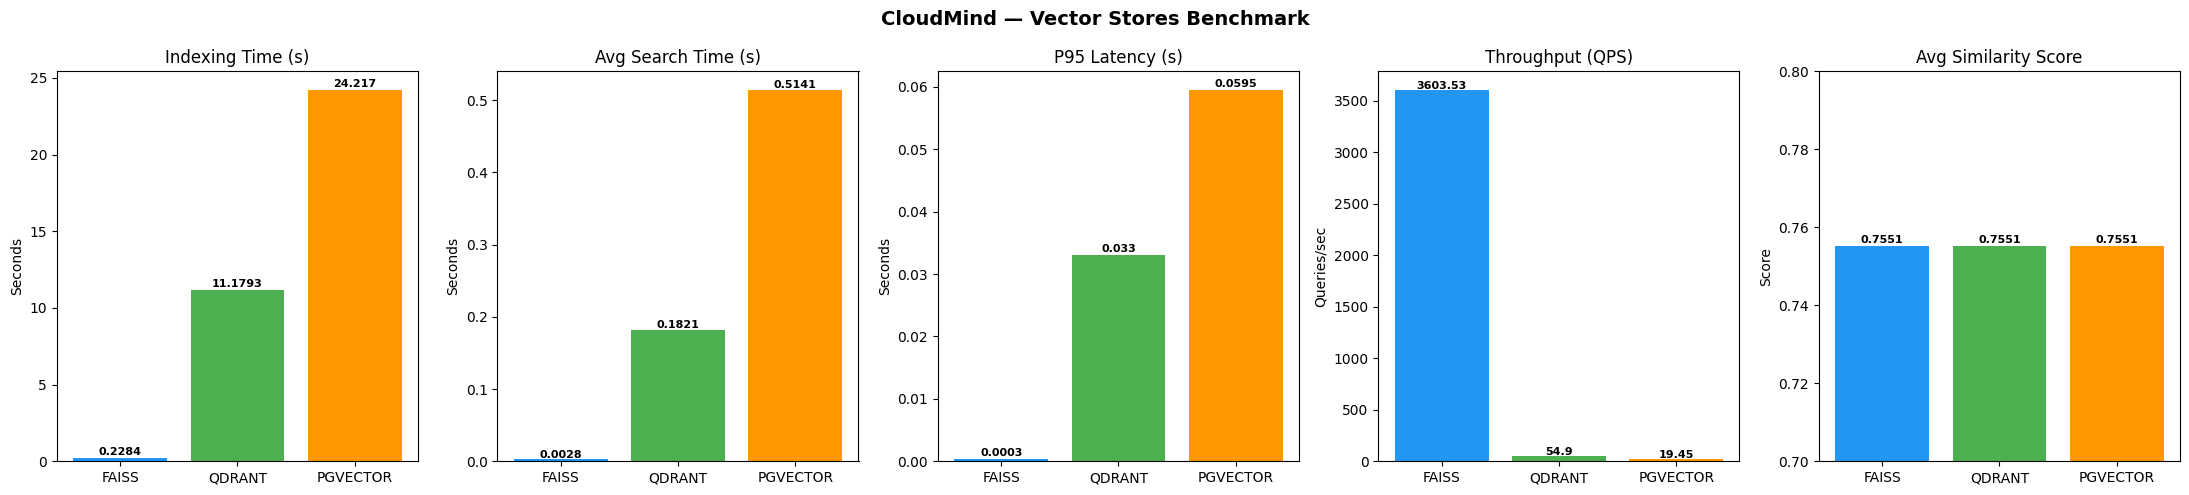

Chart saved to results/benchmarks/benchmark_chart.png


In [3]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle("CloudMind — Vector Stores Benchmark", fontsize=14, fontweight="bold")

stores = df["store"].str.upper()
colors = ["#2196F3", "#4CAF50", "#FF9800"]

# Indexing time
axes[0].bar(stores, df["indexing_time_s"], color=colors)
axes[0].set_title("Indexing Time (s)")
axes[0].set_ylabel("Seconds")
for i, v in enumerate(df["indexing_time_s"]):
    axes[0].text(i, v + 0.2, str(v), ha="center", fontweight="bold", fontsize=8)

# Search time
axes[1].bar(stores, df["avg_search_time_s"], color=colors)
axes[1].set_title("Avg Search Time (s)")
axes[1].set_ylabel("Seconds")
for i, v in enumerate(df["avg_search_time_s"]):
    axes[1].text(i, v + 0.002, str(v), ha="center", fontweight="bold", fontsize=8)

# P95 latency
axes[2].bar(stores, df["p95_latency_s"], color=colors)
axes[2].set_title("P95 Latency (s)")
axes[2].set_ylabel("Seconds")
for i, v in enumerate(df["p95_latency_s"]):
    axes[2].text(i, v + 0.0005, str(v), ha="center", fontweight="bold", fontsize=8)

# Throughput
axes[3].bar(stores, df["throughput_qps"], color=colors)
axes[3].set_title("Throughput (QPS)")
axes[3].set_ylabel("Queries/sec")
for i, v in enumerate(df["throughput_qps"]):
    axes[3].text(i, v + 10, str(v), ha="center", fontweight="bold", fontsize=8)

# Similarity score
axes[4].bar(stores, df["avg_similarity_score"], color=colors)
axes[4].set_title("Avg Similarity Score")
axes[4].set_ylabel("Score")
axes[4].set_ylim(0.7, 0.8)
for i, v in enumerate(df["avg_similarity_score"]):
    axes[4].text(i, v + 0.001, str(v), ha="center", fontweight="bold", fontsize=8)

plt.tight_layout()
plt.savefig("../results/benchmarks/benchmark_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to results/benchmarks/benchmark_chart.png")

In [4]:
print("=" * 55)
print("CLOUDMIND — VECTOR STORE BENCHMARK CONCLUSION")
print("=" * 55)

print(f"""
Dataset     : {df['n_documents'].iloc[0]:,} chunks
Embedding   : nomic-ai/nomic-embed-text-v1.5 (768 dim)
Search runs : 5

INDEXING SPEED
  FAISS    → {df[df['store']=='faiss']['indexing_time_s'].values[0]}s
  Qdrant   → {df[df['store']=='qdrant']['indexing_time_s'].values[0]}s
  Pgvector → {df[df['store']=='pgvector']['indexing_time_s'].values[0]}s

SEARCH SPEED
  FAISS    → {df[df['store']=='faiss']['avg_search_time_s'].values[0]}s
  Qdrant   → {df[df['store']=='qdrant']['avg_search_time_s'].values[0]}s
  Pgvector → {df[df['store']=='pgvector']['avg_search_time_s'].values[0]}s

P95 LATENCY
  FAISS    → {df[df['store']=='faiss']['p95_latency_s'].values[0]}s
  Qdrant   → {df[df['store']=='qdrant']['p95_latency_s'].values[0]}s
  Pgvector → {df[df['store']=='pgvector']['p95_latency_s'].values[0]}s

THROUGHPUT
  FAISS    → {df[df['store']=='faiss']['throughput_qps'].values[0]} QPS
  Qdrant   → {df[df['store']=='qdrant']['throughput_qps'].values[0]} QPS
  Pgvector → {df[df['store']=='pgvector']['throughput_qps'].values[0]} QPS

SIMILARITY SCORE
  FAISS    → {df[df['store']=='faiss']['avg_similarity_score'].values[0]}
  Qdrant   → {df[df['store']=='qdrant']['avg_similarity_score'].values[0]}
  Pgvector → {df[df['store']=='pgvector']['avg_similarity_score'].values[0]}
""")

CLOUDMIND — VECTOR STORE BENCHMARK CONCLUSION

Dataset     : 10,438 chunks
Embedding   : nomic-ai/nomic-embed-text-v1.5 (768 dim)
Search runs : 5

INDEXING SPEED
  FAISS    → 0.2284s
  Qdrant   → 11.1793s
  Pgvector → 24.217s

SEARCH SPEED
  FAISS    → 0.0028s
  Qdrant   → 0.1821s
  Pgvector → 0.5141s

P95 LATENCY
  FAISS    → 0.0003s
  Qdrant   → 0.033s
  Pgvector → 0.0595s

THROUGHPUT
  FAISS    → 3603.53 QPS
  Qdrant   → 54.9 QPS
  Pgvector → 19.45 QPS

SIMILARITY SCORE
  FAISS    → 0.7551
  Qdrant   → 0.7551
  Pgvector → 0.7551



Based on our benchmark results across 10,438 chunks from AWS, Azure, GCP and compliance documents, the three vector stores show clear performance differences.

**FAISS** is by far the fastest with 3,603 QPS and sub-millisecond search times, but its in-memory nature makes it unsuitable for production — data is lost on restart 
and metadata filtering is not natively supported.

**Pgvector** shows acceptable P95 latency but its average search time of 0.51s 
exceeds the 200ms production threshold, making it a better fit for systems 
that already rely on PostgreSQL rather than a dedicated RAG pipeline.

**Qdrant** strikes the right balance for CloudMind — 54.9 QPS with 0.18s average search time 
and 0.033s P95 latency, well within production standards. 
Combined with automatic persistence and native metadata filtering by provider (AWS/Azure/GCP), 
it is our choice for the CloudMind production pipeline.